# Leitura inicial do CSV

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("dados_clientes.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         30 non-null     int64  
 1   nome               30 non-null     object 
 2   idade              28 non-null     float64
 3   genero             30 non-null     object 
 4   renda_anual        29 non-null     float64
 5   categoria_produto  30 non-null     object 
 6   valor_compra       28 non-null     float64
 7   data_compra        26 non-null     object 
 8   regiao             30 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 2.2+ KB


In [4]:
df.head()

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste


In [5]:
df.describe()

,id_cliente,idade,renda_anual,valor_compra
count,30.000000,28.000000,29.000000,28.000000
mean,1009.733333,38.892857,157162.103675,3920.147585
std,5.918605,12.561963,142393.899659,4108.469976
min,1000.000000,18.000000,39809.346415,984.100186
25%,1005.250000,31.000000,72155.261524,2017.981504
50%,1010.000000,40.000000,165339.227930,2612.869185
75%,1014.000000,42.250000,174931.504986,4393.001473
max,1019.000000,62.000000,750000.000000,20000.000000


# Lidar com valores nulos e ausentes

In [11]:
df.isnull().sum()

id_cliente           0
nome                 0
idade                2
genero               0
renda_anual          1
categoria_produto    0
valor_compra         2
data_compra          4
regiao               0
dtype: int64

In [12]:
porcentagem_df = (df.isnull().sum() / len(df)) * 100
print(f"A porcentagem de valores nulos é {porcentagem_df}")

A porcentagem de valores nulos é id_cliente            0.000000
nome                  0.000000
idade                 6.666667
genero                0.000000
renda_anual           3.333333
categoria_produto     0.000000
valor_compra          6.666667
data_compra          13.333333
regiao                0.000000
dtype: float64


In [16]:
df["idade"] = df["idade"].fillna(df["idade"].median())
df["renda_anual"] = df["renda_anual"].fillna(df["idade"].median())
df["valor_compra"] = df["valor_compra"].fillna(df["valor_compra"].median())

In [17]:
df["data_compra"] = df["data_compra"].fillna(df["data_compra"].mode()[0])

In [18]:
df.isnull().sum()

id_cliente           0
nome                 0
idade                0
genero               0
renda_anual          0
categoria_produto    0
valor_compra         0
data_compra          0
regiao               0
dtype: int64

# Lidar com duplicatas

In [19]:
df.duplicated().sum()

np.int64(0)

# Lidar com outliers

In [21]:
import matplotlib.pyplot as plt

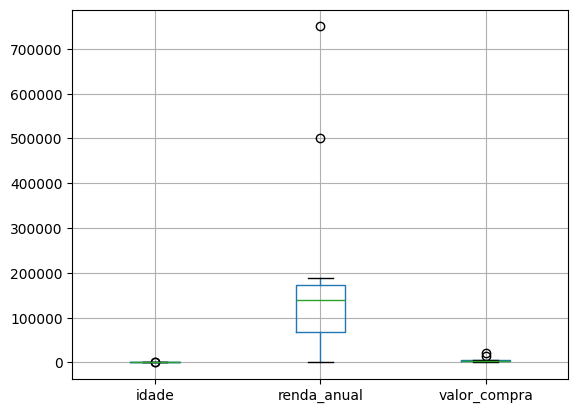

In [24]:
df.boxplot(column=['idade', 'renda_anual', 'valor_compra'])
plt.show()

In [25]:
Q1 = df["valor_compra"].quantile(0.25)
Q3 = df["valor_compra"].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

2182.9814849676877


In [28]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['valor_compra'] < limite_inferior) | 
              (df['valor_compra'] > limite_superior)]

In [31]:
outliers

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
8,1010,Bruno Lima,40.0,Outro,165339.227930,Casa,15000.0,2024-06-22,Sul
10,1007,Otávio Moura,32.0,Feminino,111934.514464,Esporte,20000.0,2024-06-22,Nordeste


# Normalização e Enconding

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['idade','renda_anual','valor_compra']] = scaler.fit_transform(
    df[['idade','renda_anual','valor_compra']]
)

In [33]:
df = pd.get_dummies(
    df,
    columns=['genero','categoria_produto','regiao'],
    drop_first=True
)

# Lidar com Datas

In [34]:
df.head()

,id_cliente,nome,idade,renda_anual,valor_compra,data_compra,genero_Masculino,genero_Outro,categoria_produto_Casa,categoria_produto_Eletrônicos,categoria_produto_Esporte,categoria_produto_Moda,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,1006,Gabriela Rocha,0.500000,1.000000,0.005301,2024-01-15,True,False,False,True,False,False,False,False,False,False
1,1019,Isabela Martins,0.545455,0.233201,0.000000,2024-04-05,False,True,True,False,False,False,False,True,False,False
2,1014,Gabriela Rocha,0.340909,0.240840,0.054369,2024/03/10,False,True,False,False,False,True,False,True,False,False
3,1010,Sabrina Torres,0.909091,0.126799,0.210211,2024/03/10,False,False,False,False,True,False,True,False,False,False
4,1007,Daniel Costa,0.545455,0.129126,0.056175,2024-06-22,False,True,False,False,False,False,False,False,False,False


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     30 non-null     int64  
 1   nome                           30 non-null     object 
 2   idade                          30 non-null     float64
 3   renda_anual                    30 non-null     float64
 4   valor_compra                   30 non-null     float64
 5   data_compra                    30 non-null     object 
 6   genero_Masculino               30 non-null     bool   
 7   genero_Outro                   30 non-null     bool   
 8   categoria_produto_Casa         30 non-null     bool   
 9   categoria_produto_Eletrônicos  30 non-null     bool   
 10  categoria_produto_Esporte      30 non-null     bool   
 11  categoria_produto_Moda         30 non-null     bool   
 12  regiao_Nordeste                30 non-null     bool 

In [38]:
df["data_compra"] = pd.to_datetime(df["data_compra"].astype(str).str.replace("/", "-"), errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   id_cliente                     30 non-null     int64         
 1   nome                           30 non-null     object        
 2   idade                          30 non-null     float64       
 3   renda_anual                    30 non-null     float64       
 4   valor_compra                   30 non-null     float64       
 5   data_compra                    29 non-null     datetime64[ns]
 6   genero_Masculino               30 non-null     bool          
 7   genero_Outro                   30 non-null     bool          
 8   categoria_produto_Casa         30 non-null     bool          
 9   categoria_produto_Eletrônicos  30 non-null     bool          
 10  categoria_produto_Esporte      30 non-null     bool          
 11  categoria_produto_Mod

In [39]:
df["ano_compra"] = df["data_compra"].dt.year
df["mes_compra"] = df["data_compra"].dt.month
df["dia_compra"] = df["data_compra"].dt.day
df["dia_semana"] = df["data_compra"].dt.day_name()